In [9]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
import pandas as pd
# Define the file path
file_path = r'E:\mlproject\notebook\stud.csv'

# Read the CSV file
df = pd.read_csv(file_path)

# Display the first few rows of the dataframe
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


This will tell you:

The number of entries in each column.
The data type of each column (e.g., int64, object).
If there are any missing values.

In [5]:
# Basic info about the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


This will show:

The count, mean, standard deviation, minimum, and maximum values of each numerical feature.
Helps to understand the distribution of scores.


In [6]:
# Descriptive statistics for numerical columns
df.describe()


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


This will give the count of missing values in each column. If there are any, you may need to handle them by imputation or removal.

In [7]:
# Check for missing values
df.isnull().sum()


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

The histograms show how the scores are distributed across students for each subject. This helps in identifying if the data is skewed or follows a normal distribution.

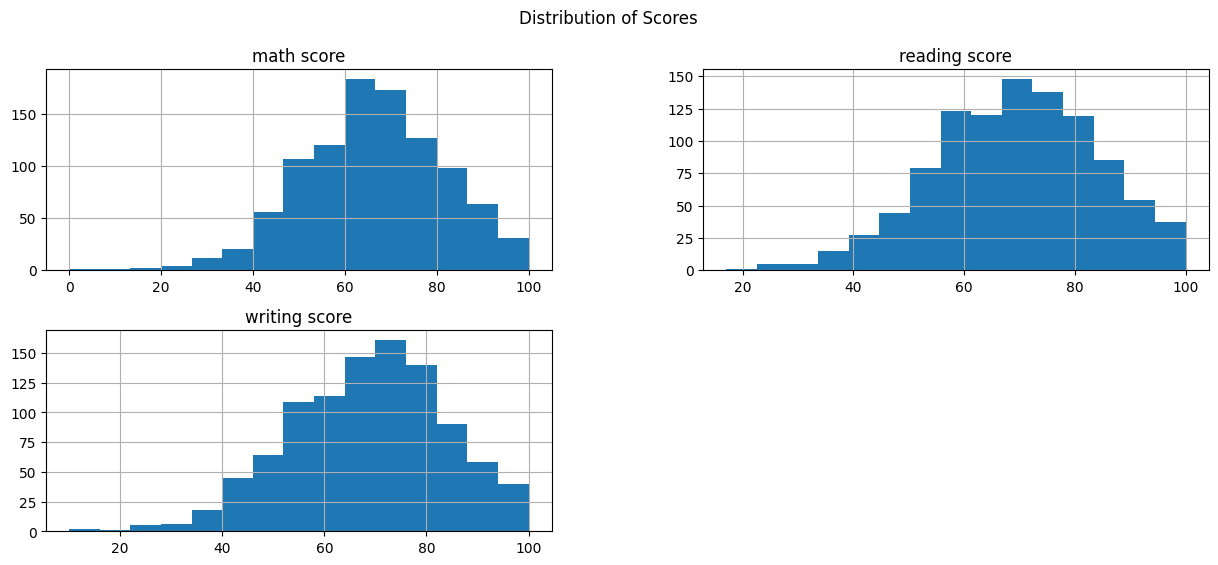

In [10]:
# Plotting histograms for numerical columns
df[['math score', 'reading score', 'writing score']].hist(bins=15, figsize=(15, 6))
plt.suptitle('Distribution of Scores')
plt.show()


This will help us understand how correlated the scores are across different subjects (e.g., are math scores highly correlated with writing scores?).




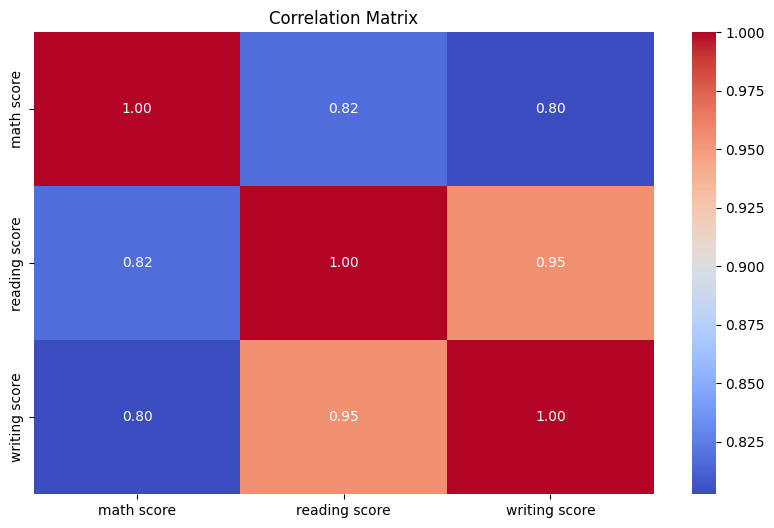

In [11]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[['math score', 'reading score', 'writing score']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


These plots show the distribution of different categories in the dataset. For example:

The gender plot shows how many males and females are in the dataset.
The parental level of education plot shows the distribution of different educational backgrounds of students' parents.


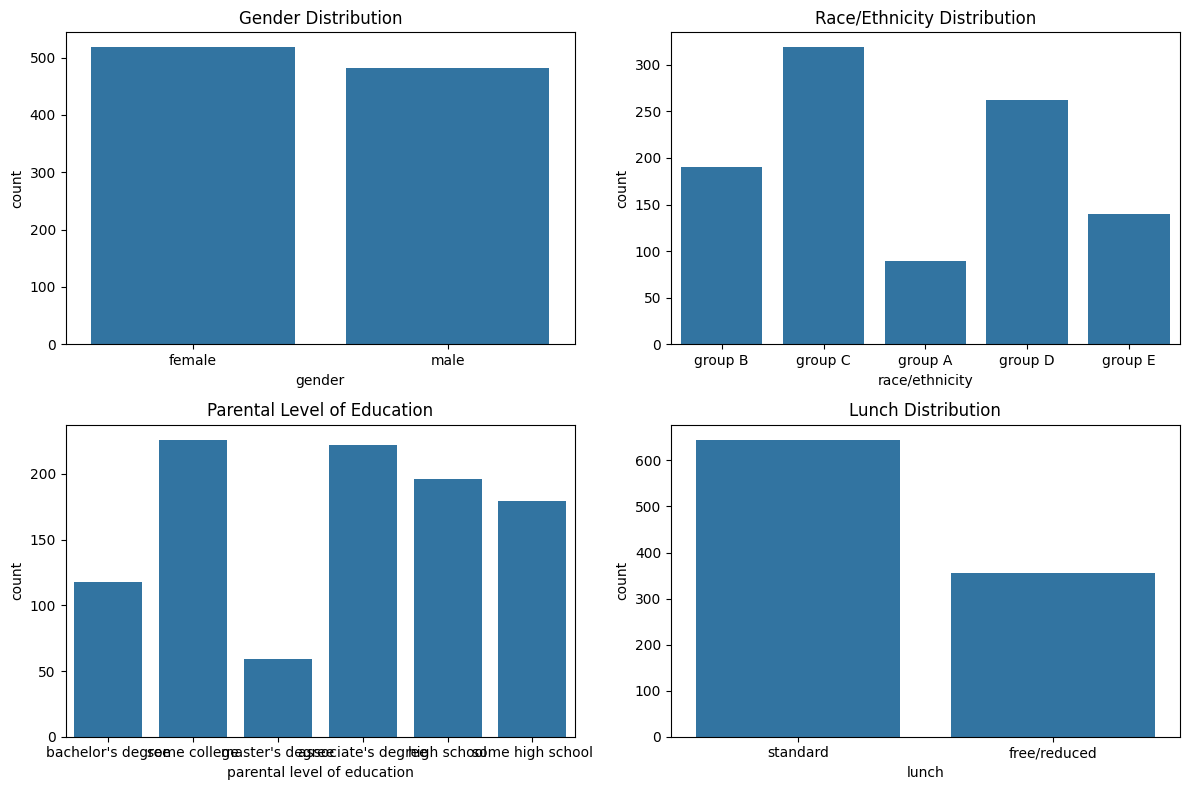

In [12]:
# Plotting categorical variables
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.countplot(data=df, x='gender')
plt.title('Gender Distribution')

plt.subplot(2, 2, 2)
sns.countplot(data=df, x='race/ethnicity')
plt.title('Race/Ethnicity Distribution')

plt.subplot(2, 2, 3)
sns.countplot(data=df, x='parental level of education')
plt.title('Parental Level of Education')

plt.subplot(2, 2, 4)
sns.countplot(data=df, x='lunch')
plt.title('Lunch Distribution')

plt.tight_layout()
plt.show()


The pairplot will allow you to visually check how the scores are correlated with each other. Scatter plots help you spot trends and outliers.


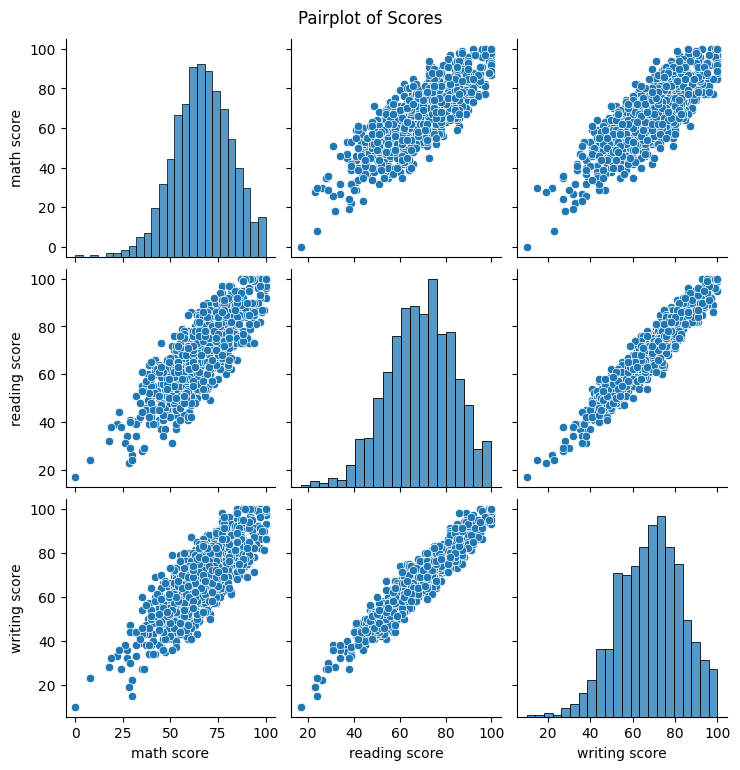

In [13]:
# Pairplot to check relationships between scores
sns.pairplot(df[['math score', 'reading score', 'writing score']])
plt.suptitle('Pairplot of Scores', y=1.02)
plt.show()


The boxplots will show you if there are any outliers (values that lie outside the whiskers) for the numerical columns. Outliers may need to be addressed depending on your model's needs.

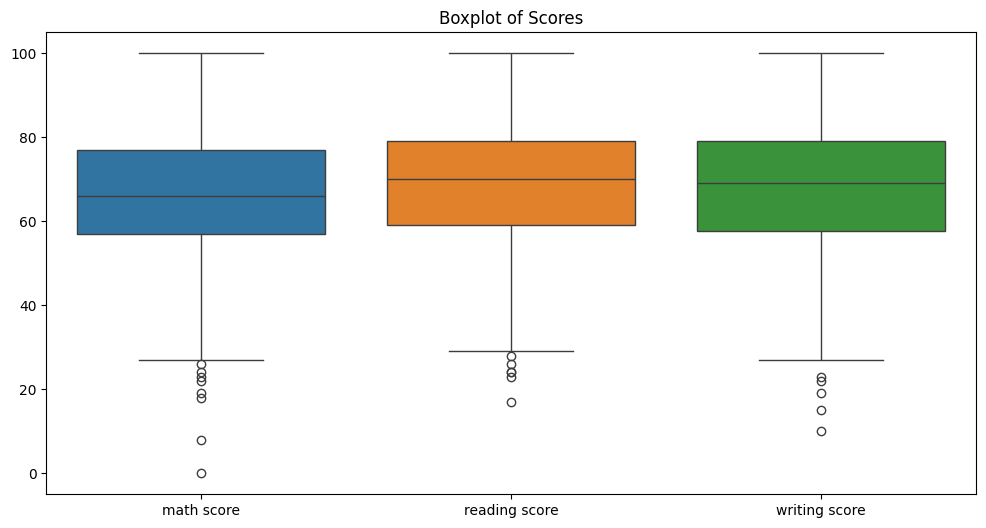

In [14]:
# Box plot for numerical columns
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['math score', 'reading score', 'writing score']])
plt.title('Boxplot of Scores')
plt.show()


Boxplots show how numerical features differ by category. For example:

The gender vs math score plot helps to compare how male and female students perform in math.

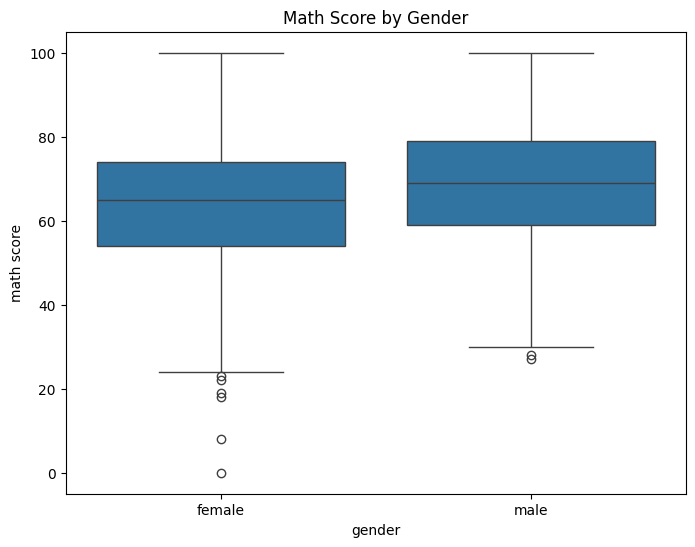

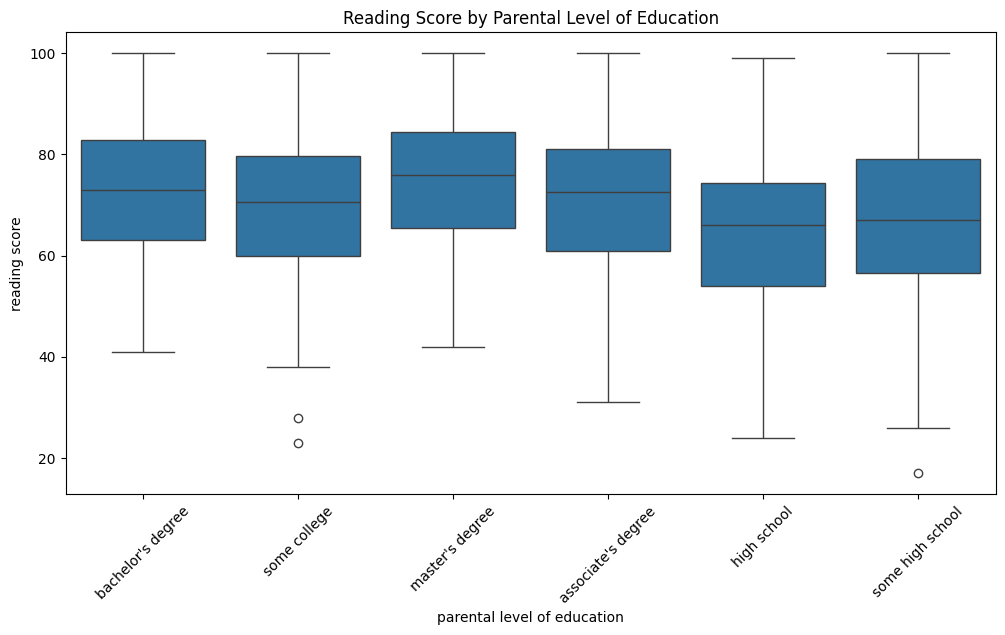

In [15]:
# Gender vs. Math Score
plt.figure(figsize=(8, 6))
sns.boxplot(x='gender', y='math score', data=df)
plt.title('Math Score by Gender')
plt.show()

# Parental level of education vs. Reading Score
plt.figure(figsize=(12, 6))
sns.boxplot(x='parental level of education', y='reading score', data=df)
plt.title('Reading Score by Parental Level of Education')
plt.xticks(rotation=45)
plt.show()


In [16]:
# Adding Total and Average Scores columns to the DataFrame
df['total_score'] = df['math score'] + df['reading score'] + df['writing score']
df['average_score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

# Display the updated DataFrame with the new columns
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


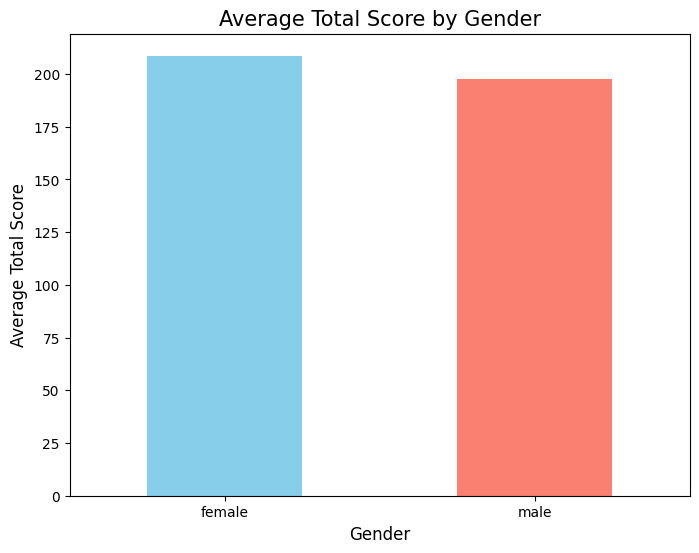

In [18]:
# Gender-wise Total Score Comparison using a Bar Plot
gender_total_score = df.groupby('gender')['total_score'].mean()

# Plotting the bar plot
plt.figure(figsize=(8, 6))
gender_total_score.plot(kind='bar', color=['skyblue', 'salmon'])

# Adding title and labels
plt.title('Average Total Score by Gender', fontsize=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Average Total Score', fontsize=12)

# Show the plot
plt.xticks(rotation=0)
plt.show()


In [19]:
# Identifying numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Columns:", numerical_cols)

# Identifying categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:", categorical_cols)


Numerical Columns: Index(['math score', 'reading score', 'writing score', 'total_score',
       'average_score'],
      dtype='object')
Categorical Columns: Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')


In [22]:
# Display categories (unique values) for all categorical features
print("Categories in Categorical Columns:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Categories in Categorical Columns:

gender:
gender
female    518
male      482
Name: count, dtype: int64

race/ethnicity:
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

parental level of education:
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

lunch:
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

test preparation course:
test preparation course
none         642
completed    358
Name: count, dtype: int64


In [24]:
# Count students who scored full marks in each individual subject

# Full marks in Math
full_marks_math = df[df['math score'] == 100].shape[0]

# Full marks in Reading
full_marks_reading = df[df['reading score'] == 100].shape[0]

# Full marks in Writing
full_marks_writing = df[df['writing score'] == 100].shape[0]

# Display the results
print(f"Number of students with full marks in Math: {full_marks_math}")
print(f"Number of students with full marks in Reading: {full_marks_reading}")
print(f"Number of students with full marks in Writing: {full_marks_writing}")


Number of students with full marks in Math: 7
Number of students with full marks in Reading: 17
Number of students with full marks in Writing: 14


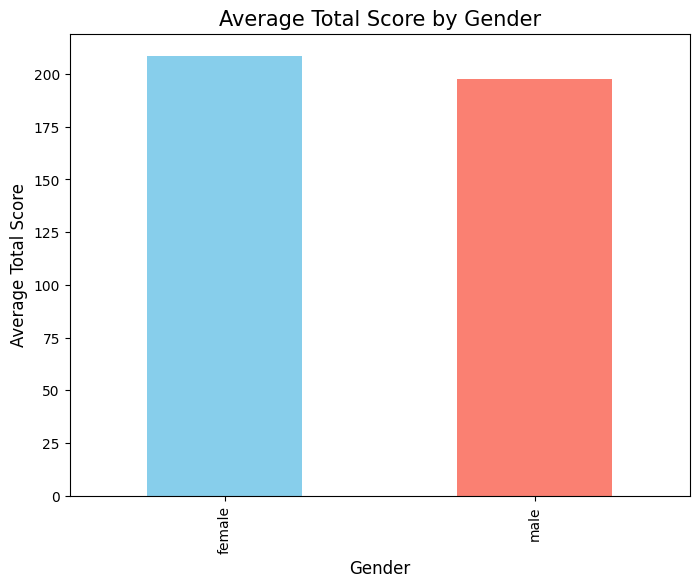

In [25]:
# Calculate the average total score by gender
gender_performance = df.groupby('gender')['total_score'].mean()

# Plotting the bar plot
plt.figure(figsize=(8, 6))
gender_performance.plot(kind='bar', color=['skyblue', 'salmon'])

# Adding title and labels
plt.title('Average Total Score by Gender', fontsize=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Average Total Score', fontsize=12)

# Show the plot
plt.show()
